# CNN applications 

Before starting this notebook, install the library ultralytics in your environment by running the following commmand. 
```
    !pip install ultralytics --upgrade
```

This will take a few minutes to complete. You must be connected to the internet to install the different libraries. 

If you are using a Mac computer, you need to run the following command 
```
    !pip install "numpy<2"
```

## It starts with a dataset 

As discussed, in most application, you will be using CNN models that other people created and trained with different datasets. 

There are hundreds (thousands) of such models, each model has its own accuracy, number of parameters, processing speed, etc. 

See [TIMMS Leaderboard](https://huggingface.co/spaces/timm/leaderboard) for a current list of models.

For instance, here is a current list of best models as of today (04/07/2026)
<div style="text-align:center">
<img src="images/imagenet_results.png" alt="plot" width="700" />
</div>

### ImageNet

To compare different models fairly, researchers developed a set of large databases that include images along with some desired output. The models are then trained on these large databases and different models are ranked according to the results they obtain for hold-out test set. Modern models are expected to be good at different tasks, so there are many available databases. These datasets are open-access, you can download them and test your models.

The first database of its type was **ImageNet.** 

ImageNet is composed of 1 million images and there 1000 categories (things like people, animals, furniture, ect). Each image was manually cropped so that it contains one object, and the object was manually identified. 

<div style="text-align:center">
<img src="images/ImageNet_sample.png" alt="plot" width="600" />
</div>

These models have 1000 outputs, identifying the likelihood that each object is in the image. Then, models receive a score, depending on weather the true object was in the top 1% of the predictions (top 1% score) or the top 5% of the predictions (top 5% score). 

As many of the ImageNet categories are very similar, using the top 1% or top 5% is a good way to not penalize the model for confusing objects that are similar. 

Here is a list of all 1000 ImageNet categories: https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

### COCO

The COCO (Common Objects in COntext) database is an extension of ImageNet that includes images with objects, and the position of those objects in the image. 

<div style="text-align:center">
<img src="images/COCOSample.png" alt="plot" width="400" />
</div>

The COCO dataset contains 330,000 images, with more than 1.5 million instances (mutiple objects per image). There are 80 different objects in the dataset. 

Here is a list of all 80 COCO categories: https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco.yaml

Some categories include:
- 0: person
- 1: bicycle
- 2: car
- 3: motorcycle
- 4: airplane
- 5: bus
- 6: train
- 7: truck
- 8: boat
- 9: traffic light
- 10: fire hydrant
- 11: stop sign

### COCO segmentation

COCO was extended so that objects in the image were segmented
<div style="text-align:center">
<img src="images/COCOSegment.avif" alt="plot" width="400" />
</div>

## COCO Pose

COCO was extended so to annotate the position of multiple body joints in images that contained people 
<div style="text-align:center">
<img src="images/COCOPose.webp" alt="plot" width="400" />
</div>



### Learning Objective

The objective of this notebook is to learn how to use models that have been trained with these different databases, and apply them to solve your own research problem. 

For this, we will use a set of models that were designed to work in real time. These models, called YOLO (You Only Look Once) provide a good balance between speed and accuracy, with an ImageNet top 5% of approximately 94% and top 1% of 75%. These models represent a good balance between speed and accuracy. 

<div style="text-align:center">
<img src="images/YOLOResults.png" alt="plot" width="600" />
</div>

If you want higher precision, you can always use other models, but YOLO models are a good starting point. 

In [1]:
PYTORCH_ENABLE_MPS_FALLBACK=1 
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

In [2]:
#load the model
model = YOLO(r'models/yolo26s.pt') #load the pretrained model, this is the smallest version of the model, it is faster to train, but less accurate than the larger versions (yolov8s.pt, yolov8m.pt, yolov8l.pt, yolov8x.pt)

In [4]:
#lest see the model
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 22.8 GFLOPs


(260, 10009784, 0, 22.838476800000002)

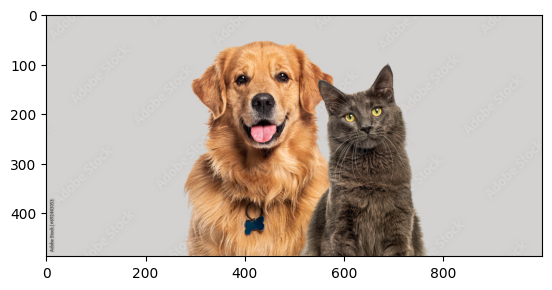

In [22]:
#let's test the model on an image
img = Image.open(r'images/cat-dog.jpg') #load the image and convert it to RGB format
plt.imshow(img) #show the image

When using YOLO models from Ultralytics, we can pass the image directly as it is. The model will take care of adjusting the image size. 

In [23]:
#process the image with the model 
results = model(img)


0: 320x640 1 cat, 1 dog, 66.8ms
Speed: 1.8ms preprocess, 66.8ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 640)


### Understanding the `results` object

`results` is a **list** returned by YOLO inference.  
Since we passed one image (`img`), `results` has length **1**.

- `results[0]` is an object for that storing the results obtained for the image.
- Main attributes in `results[0]`:
    - `boxes`: detected bounding boxes (coordinates, confidence, class id)
    - `names`: mapping from class id to class name (COCO labels)
    - `orig_img`, `orig_shape`: original image data and size
    - `speed`: preprocessing / inference / postprocessing time
    - `masks`, `keypoints`, `probs`, `obb`: task-specific outputs (often `None` for standard detection)

For this notebook, the most important field is **`results[0].boxes`**, which contains the detected objects (e.g., cat, dog) with their confidence scores and box locations.

In [24]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16., 15.])
conf: tensor([0.9358, 0.3348])
data: tensor([[2.7797e+02, 5.4158e+01, 5.8086e+02, 4.8473e+02, 9.3580e-01, 1.6000e+01],
        [5.1878e+02, 9.8897e+01, 7.6677e+02, 4.8333e+02, 3.3475e-01, 1.5000e+01]])
id: None
is_track: False
orig_shape: (487, 1000)
shape: torch.Size([2, 6])
xywh: tensor([[429.4118, 269.4423, 302.8894, 430.5685],
        [642.7776, 291.1154, 247.9944, 384.4378]])
xywhn: tensor([[0.4294, 0.5533, 0.3029, 0.8841],
        [0.6428, 0.5978, 0.2480, 0.7894]])
xyxy: tensor([[277.9671,  54.1580, 580.8565, 484.7265],
        [518.7805,  98.8966, 766.7748, 483.3344]])
xyxyn: tensor([[0.2780, 0.1112, 0.5809, 0.9953],
        [0.5188, 0.2031, 0.7668, 0.9925]])

### Information in `boxes`

`boxes = results[0].boxes` contains all detections for the image.

- `boxes.cls`: predicted class ID for each detection (COCO classes)
- `boxes.conf`: confidence score for each detection, a number between 0 and 
- `boxes.xyxy`: bounding box coordinates in pixel format `[x1, y1, x2, y2]`
- `boxes.xywh`: bounding box coordinates in providing the position to the top-left corner `[x1, y1]`, and the box width `[w]` and height `[h]`.
- `boxes.xyxyn`: same as `boxes.xyxy` but normalized by the image width `[w]` and height `[h]`.
- `boxes.xywhn`: same as `boxes.xywh` but normalized by the image width `[w]` and height `[h]`.


This means each detection can be described as:

1. Object class (e.g., `cat`, `dog`)
2. Confidence score (between 0 and 1)
3. Bounding box location in the image

We can now visualize the image and the results

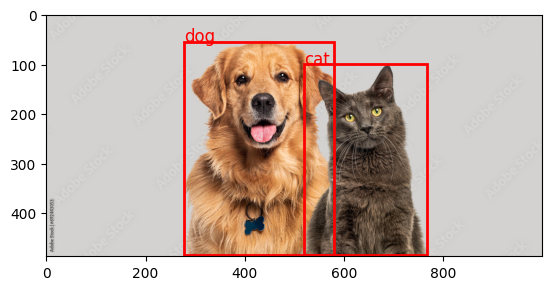

In [30]:
plt.imshow(img)
boxes = results[0].boxes.xyxy.cpu().numpy() #get the bounding boxes in xyxy format and convert to numpy array
classes = results[0].boxes.cls.cpu().numpy() #get the class labels of the detected objects and convert to numpy array
for idx, box in enumerate(boxes):
    x1, y1, x2, y2 = box
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)) #draw the bounding box on the image
    plt.text(x1, y1, f'{model.names[int(classes[idx])]}', color='red', fontsize=12) #add the class label to the bounding box
plt.show()

### Activity 1

Load the image `images/playing.jpeg` and use the YOLO model to identify the objects in the image


The folder `data/TUG` contains frames of a person performing the Time Up and Go (TUG) test. Let's look at a couple of frames.

In [3]:
#read the files in the folder
list_of_images = os.listdir(r'data/TUG')
list_of_images.sort() #sort the list of images alphabetically
#this makes sure that you only have images (MacOS creates hidden files that can cause errors when processing the images)
list_of_images = [image for image in list_of_images if image.endswith('.jpg') ]


Plot a few of the images

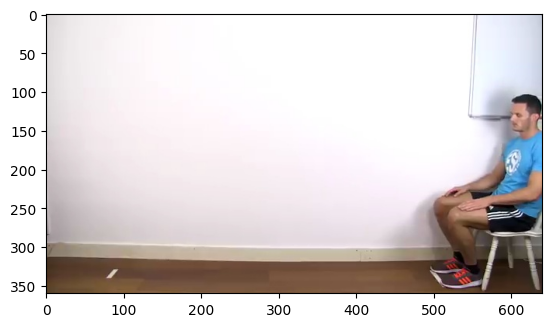

In [4]:
img = Image.open(r'data/TUG/' + list_of_images[0]) #load the first image in the folder
plt.imshow(img)

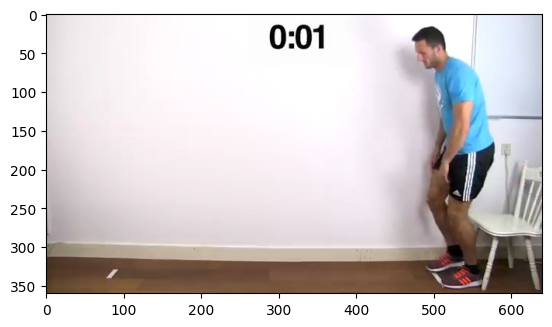

In [5]:
img = Image.open(r'data/TUG/' + list_of_images[50]) #load the first image in the folder
plt.imshow(img)

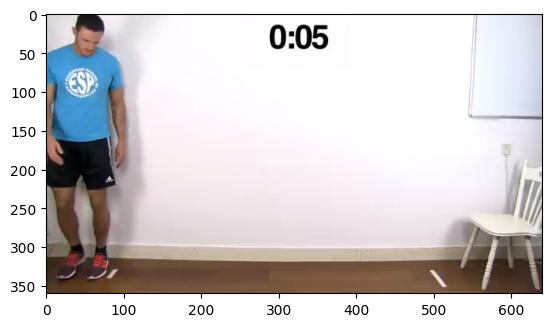

In [6]:
img = Image.open(r'data/TUG/' + list_of_images[150]) #load the first image in the folder
plt.imshow(img)

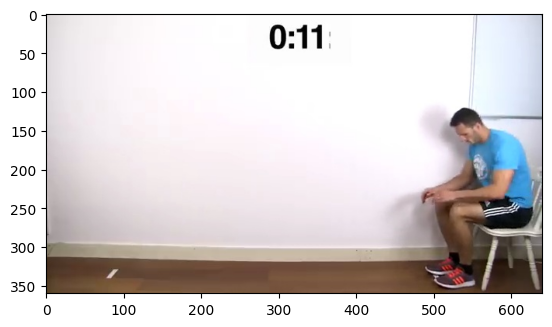

In [7]:
img = Image.open(r'data/TUG/' + list_of_images[300]) #load the first image in the folder
plt.imshow(img)


### Activity 2

Load the image `r'data/TUG/frame_0000.jpg'` and use the YOLO model to identify the objects in the image, what objects can you detect? 

We can now use a small loop to find the position of the person and the chair for each frame

In [10]:
# Class IDs for person and chair in the loaded YOLO model
target_names = {"person", "chair"}
name_to_id = {name: idx for idx, name in model.names.items()}
target_ids = [name_to_id[name] for name in target_names if name in name_to_id]

positions = []

for idx, fname in enumerate(list_of_images):
    frame_path = os.path.join("data/TUG", fname)
    #you can tell the model to only look for specific classes by passing the class IDs to the classes argument, this can speed up the processing time and reduce false positives
    #in this case, we are only interested in detecting people and chairs, so we pass the class IDs for person and chair to the model 
    r = model(frame_path, classes=target_ids, verbose=False)[0]

    frame_data = {
        "frame": idx,
        "person_x": np.nan, "person_y": np.nan, "person_w": np.nan, 
        "chair_x": np.nan,  "chair_y": np.nan,  "chair_w": np.nan,  
    }

    if r.boxes is not None and len(r.boxes) > 0:
        cls = r.boxes.cls.cpu().numpy().astype(int)
        conf = r.boxes.conf.cpu().numpy()
        xyxy = r.boxes.xyxy.cpu().numpy()  # x1, y1, x2, y2

        for label in ["person", "chair"]:
            cid = name_to_id[label]
            idx = np.where(cls == cid)[0]
            if idx.size > 0:
                best = idx[np.argmax(conf[idx])]  # highest confidence detection
                x1, y1, x2, y2 = xyxy[best]
                # Calculate center and dimensions
                x = (x1 + x2) / 2
                y = (y1 + y2) / 2
                frame_data[f"{label}_x"] = float(x)
                frame_data[f"{label}_y"] = float(y)
    positions.append(frame_data)

# Preview first few frames
positions[:5]

[{'frame': 0,
  'person_x': 567.1435546875,
  'person_y': 228.3830108642578,
  'person_w': nan,
  'chair_x': 599.1488037109375,
  'chair_y': 305.22216796875,
  'chair_w': nan},
 {'frame': 1,
  'person_x': 567.2021484375,
  'person_y': 228.60150146484375,
  'person_w': nan,
  'chair_x': 599.6994018554688,
  'chair_y': 304.8193359375,
  'chair_w': nan},
 {'frame': 2,
  'person_x': 567.1805419921875,
  'person_y': 228.6739959716797,
  'person_w': nan,
  'chair_x': 599.6885986328125,
  'chair_y': 304.98126220703125,
  'chair_w': nan},
 {'frame': 3,
  'person_x': 567.1942749023438,
  'person_y': 228.90760803222656,
  'person_w': nan,
  'chair_x': 599.907470703125,
  'chair_y': 304.6334533691406,
  'chair_w': nan},
 {'frame': 4,
  'person_x': 567.3084716796875,
  'person_y': 229.18536376953125,
  'person_w': nan,
  'chair_x': 600.0828857421875,
  'chair_y': 305.07086181640625,
  'chair_w': nan}]

In [ ]:
from matplotlib.widgets import Slider

# Build arrays from the existing `positions` list
frames = np.array([p["frame"] for p in positions])
person_x = np.array([p["person_x"] for p in positions], dtype=float)
person_y = np.array([p["person_y"] for p in positions], dtype=float)
chair_x = np.array([p["chair_x"] for p in positions], dtype=float)
chair_y = np.array([p["chair_y"] for p in positions], dtype=float)

fig, ax = plt.subplots(figsize=(7, 5))
plt.subplots_adjust(bottom=0.20)

# Full trajectories
ax.plot(person_x, person_y, color="tab:blue", alpha=0.4, label="person trajectory")
ax.plot(chair_x, chair_y, color="tab:orange", alpha=0.4, label="chair trajectory")

# Current frame markers (updated by slider)
person_pt, = ax.plot([], [], "o", color="tab:blue", markersize=8, label="person (current)")
chair_pt, = ax.plot([], [], "o", color="tab:orange", markersize=8, label="chair (current)")

ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Object positions by frame")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.invert_yaxis()  # image-like coordinates (origin at top-left)

# Slider
ax_slider = plt.axes([0.15, 0.08, 0.7, 0.04])
frame_slider = Slider(
    ax=ax_slider,
    label="Frame",
    valmin=int(frames.min()),
    valmax=int(frames.max()),
    valinit=int(frames.min()),
    valstep=1
)

def update(val):
    f = int(frame_slider.val)
    i = np.where(frames == f)[0][0]

    # Person marker
    if np.isfinite(person_x[i]) and np.isfinite(person_y[i]):
        person_pt.set_data([person_x[i]], [person_y[i]])
    else:
        person_pt.set_data([], [])

    # Chair marker
    if np.isfinite(chair_x[i]) and np.isfinite(chair_y[i]):
        chair_pt.set_data([chair_x[i]], [chair_y[i]])
    else:
        chair_pt.set_data([], [])

    ax.set_title(f"Object positions - frame {f}")
    fig.canvas.draw_idle()

frame_slider.on_changed(update)
update(frames.min())
plt.show()

Note: you may need to restart the kernel to use updated packages.
